# Preprocesamiento de Datos
## Telco Customer Churn - Pipeline de Preparación

## 1. Importar Módulos

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import (
    load_data, clean_data, drop_unnecessary_columns,
    split_features_target, identify_column_types,
    encode_columns, scale_features, apply_smote, preprocess_data
)
from src.feature_engineering import engineer_features
import warnings
warnings.filterwarnings('ignore')

print("Módulos importados correctamente.")

Módulos importados correctamente.


## 2. Cargar Datos

In [2]:
df_raw = load_data('../data/raw/Telco_customer_churn.xlsx')
print(f"Dimensiones originales: {df_raw.shape}")

Datos cargados: 7043 filas, 33 columnas
Dimensiones originales: (7043, 33)


## 3. Limpieza de Datos

In [3]:
df_clean = clean_data(df_raw)
print(f"Dimensiones después de limpieza: {df_clean.shape}")
print(f"Valores nulos después de limpieza:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

Dimensiones después de limpieza: (7043, 33)
Valores nulos después de limpieza:
Series([], dtype: int64)


## 4. Eliminar Columnas Irrelevantes

In [4]:
df_clean = drop_unnecessary_columns(df_clean)
print(f"Dimensiones después de eliminar columnas: {df_clean.shape}")
print(f"\nColumnas restantes ({len(df_clean.columns)}):")
for c in df_clean.columns:
    print(f"  - {c}: {df_clean[c].dtype}")

Dimensiones después de eliminar columnas: (7043, 20)

Columnas restantes (20):
  - Gender: str
  - Senior Citizen: str
  - Partner: str
  - Dependents: str
  - Tenure Months: int64
  - Phone Service: str
  - Multiple Lines: str
  - Internet Service: str
  - Online Security: str
  - Online Backup: str
  - Device Protection: str
  - Tech Support: str
  - Streaming TV: str
  - Streaming Movies: str
  - Contract: str
  - Paperless Billing: str
  - Payment Method: str
  - Monthly Charges: float64
  - Total Charges: float64
  - Churn Value: int64


## 5. Ingeniería de Características

In [5]:
df_feat = engineer_features(df_clean)
print(f"\nDimensiones después de feature engineering: {df_feat.shape}")
df_feat.head(3)

Aplicando ingeniería de características...
Nuevas variables creadas: ['Avg Monthly Spend', 'Tenure Group', 'Num Services', 'Has Internet', 'Premium Customer', 'New Customer', 'Has Dependents or Partner', 'Engagement Score']
Shape después de feature engineering: (7043, 28)

Dimensiones después de feature engineering: (7043, 28)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Total Charges,Churn Value,Avg Monthly Spend,Tenure Group,Num Services,Has Internet,Premium Customer,New Customer,Has Dependents or Partner,Engagement Score
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,54.0750,0-6 meses,3,1,0,1,0,0.375
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,151.65,1,75.8250,0-6 meses,1,1,0,1,1,0.125
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,820.50,1,102.5625,6-12 meses,5,1,0,0,1,0.625


## 6. Split Features / Target

In [6]:
X, y = split_features_target(df_feat, 'Churn Value')
print(f"Features: {X.shape}")
print(f"Target distribution:")
print(f"  0 (No Churn): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  1 (Churn):    {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

Features: (7043, 27)
Target distribution:
  0 (No Churn): 5174 (73.5%)
  1 (Churn):    1869 (26.5%)


## 7. Identificar Tipos de Columnas

In [7]:
binary_cols, multi_cat_cols, numeric_cols = identify_column_types(X)
print(f"Columnas binarias ({len(binary_cols)}): {binary_cols}")
print(f"\nColumnas multicategóricas ({len(multi_cat_cols)}): {multi_cat_cols}")
print(f"\nColumnas numéricas ({len(numeric_cols)}): {numeric_cols}")

Columnas binarias (4): ['Has Internet', 'Premium Customer', 'New Customer', 'Has Dependents or Partner']

Columnas multicategóricas (17): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure Group']

Columnas numéricas (6): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend', 'Num Services', 'Engagement Score']


## 8. Codificación de Variables

In [8]:
# Codificar antes del split para mantener consistencia
X_encoded, encoders = encode_columns(X, binary_cols, multi_cat_cols)
print(f"Dimensiones después de codificación: {X_encoded.shape}")
print(f"\nColumnas después de codificación ({len(X_encoded.columns)}):")
for c in X_encoded.columns:
    print(f"  - {c}")

Dimensiones después de codificación: (7043, 42)

Columnas después de codificación (42):
  - Tenure Months
  - Monthly Charges
  - Total Charges
  - Avg Monthly Spend
  - Num Services
  - Has Internet
  - Premium Customer
  - New Customer
  - Has Dependents or Partner
  - Engagement Score
  - Gender_Male
  - Senior Citizen_Yes
  - Partner_Yes
  - Dependents_Yes
  - Phone Service_Yes
  - Multiple Lines_No phone service
  - Multiple Lines_Yes
  - Internet Service_Fiber optic
  - Internet Service_No
  - Online Security_No internet service
  - Online Security_Yes
  - Online Backup_No internet service
  - Online Backup_Yes
  - Device Protection_No internet service
  - Device Protection_Yes
  - Tech Support_No internet service
  - Tech Support_Yes
  - Streaming TV_No internet service
  - Streaming TV_Yes
  - Streaming Movies_No internet service
  - Streaming Movies_Yes
  - Contract_One year
  - Contract_Two year
  - Paperless Billing_Yes
  - Payment Method_Credit card (automatic)
  - Payment 

## 9. Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} ({(1-0.2)*100:.0f}%)")
print(f"Test:  {X_test.shape} (20%)")
print(f"\nDistribución en Train:")
print(f"  0: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  1: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nDistribución en Test:")
print(f"  0: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  1: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Train: (5634, 42) (80%)
Test:  (1409, 42) (20%)

Distribución en Train:
  0: 4139 (73.5%)
  1: 1495 (26.5%)

Distribución en Test:
  0: 1035 (73.5%)
  1: 374 (26.5%)


## 10. Escalado de Variables Numéricas

In [10]:
numeric_features = [c for c in numeric_cols if c in X_train.columns]
print(f"Variables a escalar: {numeric_features}")

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, numeric_features)
print(f"\nX_train antes del escalado (primeras 5 filas, primeras columnas numéricas):")
print(X_train[numeric_features].head())
print(f"\nX_train después del escalado:")
print(X_train_scaled[numeric_features].head())

Variables a escalar: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend', 'Num Services', 'Engagement Score']

X_train antes del escalado (primeras 5 filas, primeras columnas numéricas):
      Tenure Months  Monthly Charges  Total Charges  Avg Monthly Spend  \
4626             35            49.20        1701.65          48.618571   
4192             15            75.10        1151.55          76.770000   
5457             13            40.55         590.35          45.411538   
4717             26            73.50        1905.70          73.296154   
4673              1            44.55          44.55          44.550000   

      Num Services  Engagement Score  
4626             3             0.375  
4192             2             0.250  
5457             3             0.375  
4717             5             0.625  
4673             1             0.125  

X_train después del escalado:
      Tenure Months  Monthly Charges  Total Charges  Avg Monthly Spend  \
4626   

## 11. Manejo de Desbalance con SMOTE

Distribución antes de SMOTE: Counter({0: 4139, 1: 1495})

SMOTE aplicado. Shape original X_train: (5634, 42)
Shape después de SMOTE X_train: (8278, 42)
Distribución después de SMOTE:
Churn Value
0    4139
1    4139
Name: count, dtype: int64

Distribución después de SMOTE: Counter({0: 4139, 1: 4139})


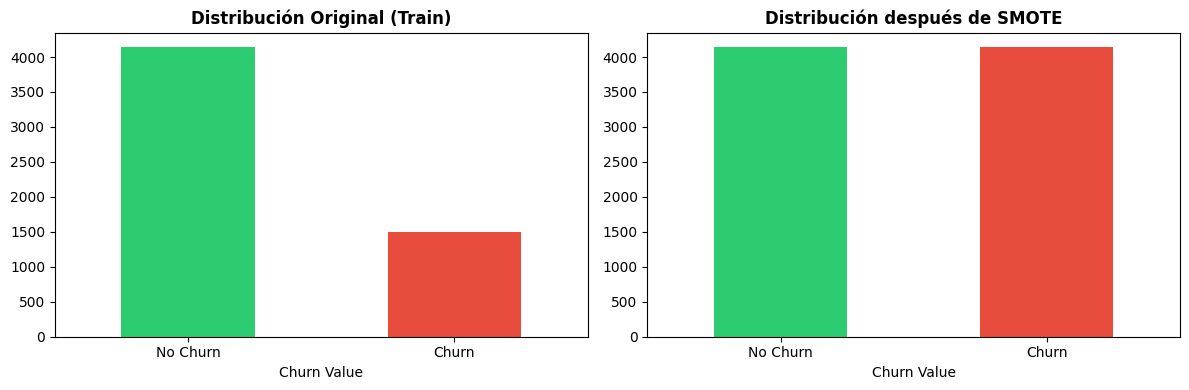

In [11]:
from collections import Counter
print(f"Distribución antes de SMOTE: {Counter(y_train)}")

X_train_res, y_train_res = apply_smote(X_train_scaled, y_train, random_state=42)

print(f"\nDistribución después de SMOTE: {Counter(y_train_res)}")

# Visualizar el balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución Original (Train)', fontweight='bold')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

pd.Series(y_train_res).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribución después de SMOTE', fontweight='bold')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Guardar Resultados del Preprocesamiento

In [12]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Guardar artefactos
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(encoders, '../models/encoders.pkl')

# Guardar datos procesados
prep_data = {
    'X_train': X_train_res,
    'X_test': X_test_scaled,
    'y_train': y_train_res,
    'y_test': y_test,
    'feature_names': list(X_encoded.columns),
    'binary_cols': binary_cols,
    'multi_cat_cols': multi_cat_cols,
    'numeric_cols': numeric_cols
}
joblib.dump(prep_data, '../data/processed/preprocessed_data.pkl')
print("Datos preprocesados guardados correctamente.")

print("\nPipeline de preprocesamiento completado exitosamente.")
print(f"\nResumen Final:")
print(f"  X_train: {X_train_res.shape}")
print(f"  X_test:  {X_test_scaled.shape}")
print(f"  y_train: {y_train_res.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"  Features: {len(X_encoded.columns)}")

Datos preprocesados guardados correctamente.

Pipeline de preprocesamiento completado exitosamente.

Resumen Final:
  X_train: (8278, 42)
  X_test:  (1409, 42)
  y_train: (8278,)
  y_test:  (1409,)
  Features: 42
